In [1]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [2]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [3]:
(X_train,y_train),(X_test,y_test)=load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [5]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

Text(0.5, 1.0, 'class is 5')

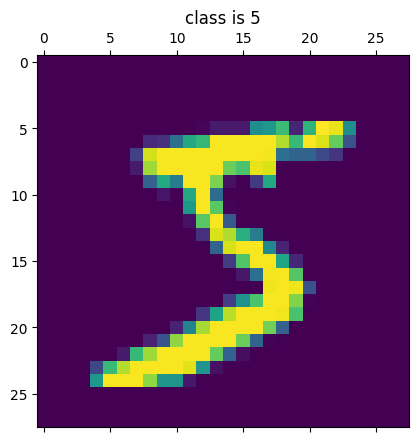

In [6]:
import matplotlib.pyplot as plt
plt.matshow(X_train[0])
plt.title(f"class is {y_train[0]}")

In [7]:
#preprocessing
#will be read in form of pixel intemsities between 0 to 255
import numpy as np
np.max(X_train),np.min(X_train)

(np.uint8(255), np.uint8(0))

In [8]:
X_train=X_train/255
X_test=X_test/255

In [9]:
np.max(X_train),np.min(X_train)

(np.float64(1.0), np.float64(0.0))

In [10]:
np.max(X_test),np.min(X_test)

(np.float64(1.0), np.float64(0.0))

Text(0.5, 1.0, 'class is 5')

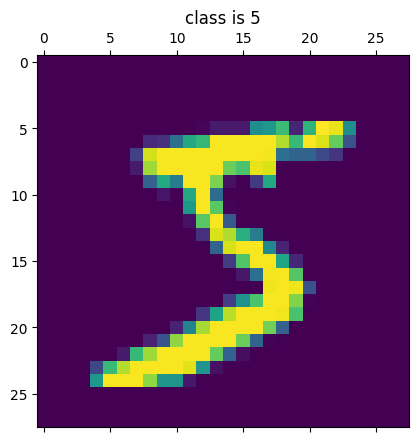

In [11]:
import matplotlib.pyplot as plt
plt.matshow(X_train[0])
plt.title(f"class is {y_train[0]}")

In [12]:
#flattening---converting multi dim data into 1 d data
X_train=X_train.reshape(60000,784)
X_test=X_test.reshape(10000,784)

In [13]:

y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [14]:
y_train=tf.keras.utils.to_categorical(y_train)
y_test=tf.keras.utils.to_categorical(y_test)

In [15]:
y_train[:5]# converted to one hot representation

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [16]:
model=Sequential()
model.add(Dense(256,activation='relu',input_shape=[784,],name="h1"))
model.add(Dense(128,activation='relu',name="h2"))
model.add(Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
history=model.fit(x=X_train,y=y_train,
                  epochs=25,
                  batch_size=32,
                  validation_data=(X_test,y_test))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8961 - loss: 0.3478 - val_accuracy: 0.9675 - val_loss: 0.1093
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9726 - loss: 0.0916 - val_accuracy: 0.9751 - val_loss: 0.0887
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9818 - loss: 0.0620 - val_accuracy: 0.9693 - val_loss: 0.1199
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9861 - loss: 0.0482 - val_accuracy: 0.9779 - val_loss: 0.0829
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9890 - loss: 0.0382 - val_accuracy: 0.9785 - val_loss: 0.0933
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9918 - loss: 0.0317 - val_accuracy: 0.9787 - val_loss: 0.0997
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9922 - loss: 0.0255 - val_accuracy: 0.9786 - val_loss: 0.1008
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9943 - loss: 0

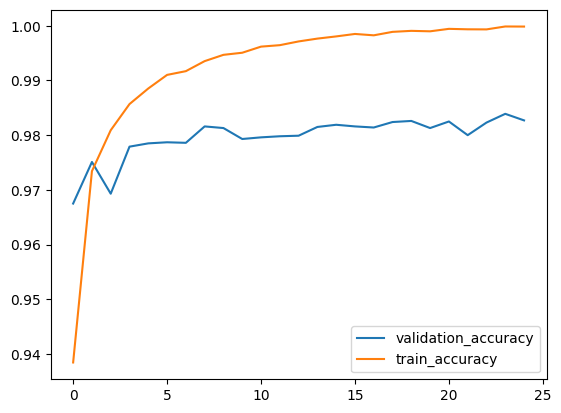

In [19]:
h=history.history
plt.plot(h['val_accuracy'],
label=['validation_accuracy'])
plt.plot(h['accuracy'],label='train_accuracy')
plt.legend()
plt.show()

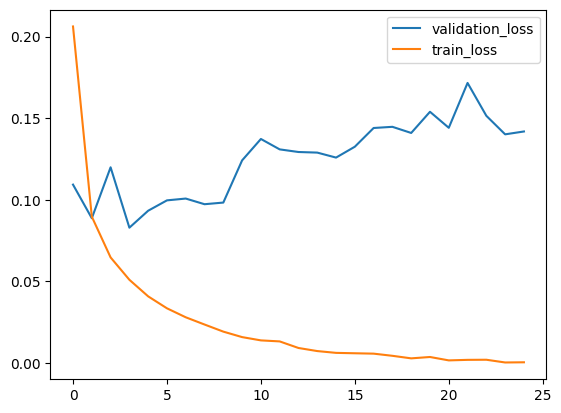

In [20]:
h=history.history
plt.plot(h['val_loss'],
label=['validation_loss'])
plt.plot(h['loss'],label='train_loss')
plt.legend()
plt.show()

In [21]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9790 - loss: 0.1822


[0.1418723464012146, 0.982699990272522]